In [60]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [62]:
config_survey_qso_fishlss = {'survey_type': 'qso_fishlss',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000,
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [None],
                 'tracers' : ['QSO_qlf'],
                 'limiting_mag_band': ['r'],
                    'color' : ['k']}

config_survey_qso_fishlss = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [None, ],
                 'limiting_mag_band': ['r', 'r', 'i', 'z'],
                 'tracers' : ['QSO_qlf'],
                    'color' : ['k', 'm','g','r']}

In [63]:
config_survey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_qso_fishlss,
                                                                                        mag_max_eval_range=[[23, 25]],
                                                                                        max_mag=None)   

QSO_qlf


In [64]:
z = config_survey_update['QSO_qlf_redshift_centers']
mag = config_survey_update['QSO_qlf_mag_centers']
nz = config_survey_update['QSO_qlf_spec_redshift_density']
bz = config_survey_update['QSO_qlf_mean_bias_redshift']
ndeg2_spec = config_survey_update['QSO_qlf_spec_density']
ndeg2_target = config_survey_update['QSO_qlf_target_density']

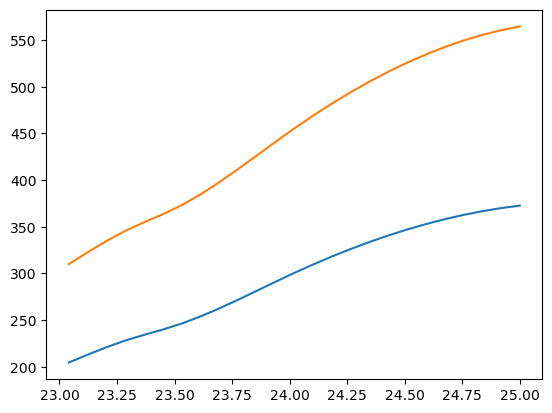

In [65]:
plt.plot(mag, ndeg2_spec)
plt.plot(mag, ndeg2_target)